In [115]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy import stats
from scipy.stats import shapiro, levene, f_oneway, kruskal, mannwhitneyu
from scipy.stats import f_oneway
from itertools import combinations
import seaborn as sns
import glob
import pingouin as pg
from scipy.stats import ttest_ind 
from factor_analyzer import FactorAnalyzer
import re
from wordcloud import WordCloud
import nltk
import string
from collections import Counter
import pyxdf

# Main values

In [116]:
Group_name = {"A","B"}
pre_survey_folder = "Data\\pre\\*.xlsx"
post_survey_folder = "Data\\post\\*.xlsx"


# loadning data

In [117]:
pre_path = glob.glob(pre_survey_folder)
print(len(pre_path))
pre_df = pd.read_excel(pre_path[0], sheet_name=0)
pre_df 

1


,ID,Starttidspunkt,Færdiggørelsestidspunkt,Mail,Navn,Senest ændret tidspunkt,Do you consent?,What is your age?,Do you use glasses?,VR,Bartending,Are you currently under the effect of anything that can enhance motion sickness or affect your heart rate?,Your test Number (Get your test conductor to fill this out)
0,1,2025-05-15 12:23:46,2025-05-15 12:32:28,anonymous,NaN,NaN,Yes,25-30,No,Quite a bit,A little,adderall for ADHD;,101
1,2,2025-05-15 12:56:28,2025-05-15 13:10:05,anonymous,NaN,NaN,Yes,18-24,No,A little,Medium,Caffeine;I+m pretty sensitive t motion sickness;,102
2,3,2025-05-15 13:27:35,2025-05-15 13:30:52,anonymous,NaN,NaN,Yes,25-30,No,A little,A little,None;,103
3,4,2025-05-16 11:30:55,2025-05-16 11:36:03,anonymous,NaN,NaN,Yes,25-30,No,A lot,NaN,None;,104
4,5,2025-05-16 12:21:33,2025-05-16 13:00:55,anonymous,NaN,NaN,Yes,18-24,No,Quite a bit,A little,Caffeine;,105
5,6,2025-05-16 13:22:48,2025-05-16 13:27:36,anonymous,NaN,NaN,Yes,18-24,Yes,A little,A little,Caffeine;,106


In [118]:
post_path = glob.glob(post_survey_folder)
print(len(post_path))
post_pf = pd.read_excel(post_path[0], sheet_name=0)

def extract_number(val):
    if pd.isnull(val):
        return np.nan
    nums = re.findall(r'\d+', str(val))
    return int(nums[0]) if nums else np.nan

# Define mapping for group names
group_map = {"Diff 1": "A", "Diff 3": "B"}

def changeGroupName(val):
    return group_map.get(str(val), np.nan)

post_pf.iloc[:, 6] = post_pf.iloc[:, 6].apply(extract_number)
post_pf.iloc[:, 7] = post_pf.iloc[:, 7].apply(changeGroupName)
post_pf


1


,ID,Starttidspunkt,Færdiggørelsestidspunkt,Mail,Navn,Senest ændret tidspunkt,Participant Number (Test conductor fills out),What group did the participant start with? (Test conductor fills out)\n,"How mentally demanding was the task? (1 being ""Very low"" and 20 being ""Very high"")","How physically demanding was the task? (1 being ""Very low"" and 20 being ""Very high"")",...,"How hurried or rushed was the pace of the task? (1 being ""Very low"" and 20 being ""Very high"")2","How successful were you in accomplishing what you were asked to do? (1 being ""Very low"" and 20 being ""Very high"")2","How hard did you have to work to accomplish your level of performance? (1 being ""Very low"" and 20 being ""Very high"")2","How insecure, discouraged, irritated, stressed, and annoyed were you? (1 being ""Very low"" and 20 being ""Very high"")2",I experienced motion sickness,I felt comfortable using the system,I felt uncomfortable using the system,I would like to play more of this,I enjoyed my time,Please provide any written feedback if any
0,1,2025-05-15 12:54:15,2025-05-15 12:55:05,anonymous,NaN,NaN,101,A,6,4,...,NaN,NaN,NaN,NaN,1,3,2,3,4,NaN
1,2,2025-05-15 12:56:15,2025-05-15 13:29:27,anonymous,NaN,NaN,102,B,15,3,...,NaN,NaN,NaN,NaN,5,3,2,4,4,NaN
2,3,2025-05-15 13:29:50,2025-05-15 13:51:55,anonymous,NaN,NaN,103,A,14,5,...,NaN,NaN,NaN,NaN,2,4,3,5,5,5m is a bit short if you don´t know what work ...
3,4,2025-05-16 11:58:27,2025-05-16 11:58:34,anonymous,NaN,NaN,104,B,20,10,...,20.0,20.0,10.0,1.0,1,4,1,4,5,"I'm not that short. :( but very good, but y..."
4,5,2025-05-16 12:03:01,2025-05-16 13:22:33,anonymous,NaN,NaN,105,A,2,3,...,6.0,12.0,13.0,1.0,1,5,5,5,5,Turning sucks unfortunately
5,6,2025-05-16 13:27:54,2025-05-16 13:49:04,anonymous,NaN,NaN,106,B,11,6,...,4.0,15.0,13.0,3.0,1,4,2,4,4,Shaker got stolen :((


In [119]:
def load_xdf_streams_to_df(base_folder):
    """
    Loads relevant .xdf files for each participant and returns a dictionary:
    {participant_id: {session_type: {stream_name: DataFrame}}}
    """
    # Only files containing these substrings are loaded
    needed_keywords = ["Baseline__old", "HighFi_high_difficulty", "task-HighFi_low_difficulty"]
    participant_data = {}

    for participant_folder in os.listdir(base_folder):
        part_path = os.path.join(base_folder, participant_folder)
        if not os.path.isdir(part_path):
            continue

        # Find relevant xdf files
        xdf_files = []
        for keyword in needed_keywords:
            xdf_files.extend(glob.glob(os.path.join(part_path, f"*{keyword}*.xdf")))

        if not xdf_files:
            continue

        participant_id = participant_folder
        print(participant_id)
        participant_data[participant_id] = {}

        for xdf_file in xdf_files:
            session_type = None
            for keyword in needed_keywords:
                if keyword in xdf_file:
                    session_type = keyword
                    break
            if not session_type:
                continue

            try:
                streams, header = pyxdf.load_xdf(xdf_file)
            except Exception as e:
                print(f"Error loading {xdf_file}: {e}")
                continue

            # Store each stream as a DataFrame
            session_streams = {}
            for stream in streams:
                stream_name = stream["info"]["name"][0]
                data = stream["time_series"]
                columns = []
                # Try to get channel labels if available
                try:
                    channels = stream["info"]["desc"][0]["channels"][0]["channel"]
                    columns = [ch["label"][0] for ch in channels]
                except Exception:
                    columns = [f"ch_{i}" for i in range(len(data[0]))] if data else []
                df = pd.DataFrame(data, columns=columns)
                df["time_stamps"] = stream["time_stamps"]
                session_streams[stream_name] = df

            participant_data[participant_id][session_type] = session_streams

    return participant_data

# Example usage:
base_folder = "Data/behvorial_physlogical"
session_data = load_xdf_streams_to_df(base_folder)


ses-101
ses-102
ses-103
ses-104
ses-105
ses-106


# Important functions

In [120]:
def calculate_omega(data):
    fa = FactorAnalyzer(n_factors=1, rotation=None)
    fa.fit(data)
    loadings = fa.loadings_[:, 0]
    uniquenesses = fa.get_uniquenesses()
    numerator = np.sum(loadings)**2
    denominator = numerator + np.sum(uniquenesses)
    return numerator / denominator

In [121]:
# score meaning is (Source: Steiner, 2003, p102)
def interpret_omega(score):
    if score > 0.9:
        return "Excellent"
    elif 0.7 <= score <= 0.9:
        return "Good"
    elif 0.6 <= score < 0.7:
        return "Acceptable"
    elif 0.5 <= score < 0.6:
        return "Poor"
    else:
        return "Unacceptable"

In [122]:
def print_out_latex_from_dataframe(df, name=None):
    clean_headers = [col.replace('-', ' ').replace('_', ' ').title() for col in df.columns]
    df_clean = df.copy()
    df_clean.columns = clean_headers

    if name is None:
        name = "_".join([h.replace(' ', '') for h in clean_headers[:3]]) + "_table"

    stringheader = ", ".join(clean_headers)
    print(
        "\\begin{figure}\n"
        "\\centering\n"
        f"{df_clean.to_latex(index=False, float_format='%.2f', escape=False)}\n"
        f"\\caption{{A table showing the {name.replace('_', ' ')} with the headers: {stringheader}}}\n"
        f"\\label{{tab:{name}}}\n"
        "\\end{figure}\n"
    )

In [123]:
def swap_group(val):
    return "B" if val == "A" else "A"

In [124]:
def compare_two_groups(df, score_col="IEQ Score", group_col="Group"):
    """
    Tests assumptions for t-test between two groups and runs either t-test or Mann-Whitney U test.
    Returns 1 if t-test was used, 0 if Mann-Whitney U was used, -1 if not enough data.
    """
    print(f"\n# Comparison for '{score_col}' between two groups in '{group_col}' #\n")
    groups = df[group_col].dropna().unique()
    if len(groups) != 2:
        print("❌ This function is for exactly two groups only.")
        return -1

    group1, group2 = groups
    data1 = df[df[group_col] == group1][score_col].dropna()
    data2 = df[df[group_col] == group2][score_col].dropna()

    print(f"Group 1: {group1} (n={len(data1)})")
    print(f"Group 2: {group2} (n={len(data2)})\n")

    # Shapiro–Wilk Test for Normality
    print("## Shapiro–Wilk Test for Normality ##")
    normal1 = normal2 = False
    if len(data1) >= 3:
        stat1, p1 = shapiro(data1)
        normal1 = p1 > 0.05
        print(f"  {group1}: Stat = {stat1:.4f}, p = {p1:.4f} → {'Normal' if normal1 else 'Not normal'}")
    else:
        print(f"  {group1}: Not enough data (n={len(data1)}) to test normality.")

    if len(data2) >= 3:
        stat2, p2 = shapiro(data2)
        normal2 = p2 > 0.05
        print(f"  {group2}: Stat = {stat2:.4f}, p = {p2:.4f} → {'Normal' if normal2 else 'Not normal'}")
    else:
        print(f"  {group2}: Not enough data (n={len(data2)}) to test normality.")

    # Levene’s Test for Equal Variances
    print("\n## Levene’s Test for Equal Variances ##")
    if len(data1) >= 2 and len(data2) >= 2:
        stat_lev, p_lev = levene(data1, data2)
        equal_var = p_lev > 0.05
        print(f"  Stat = {stat_lev:.4f}, p = {p_lev:.4f} → {'Equal variances' if equal_var else 'Unequal variances'}")
    else:
        equal_var = False
        print("  Not enough data to test variance.")

    # Decide and run test
    print(f"\n# Final Group Comparison Test for '{score_col}' #")
    if normal1 and normal2 and equal_var:
        print("✅ All assumptions met. Running independent t-test:")
        stat, p = ttest_ind(data1, data2, equal_var=True)
        print(f"  t-test: Stat = {stat:.4f}, p = {p:.4f}")
        return 1 , p
    else:
        print("❌ Assumptions not met. Using Mann-Whitney U test:")
        if len(data1) > 0 and len(data2) > 0:
            stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
            print(f"  Mann-Whitney U: Stat = {stat:.4f}, p = {p:.4f}")
            return 0 , p
        else:
            print("  Not enough data for Mann-Whitney U test.")
            return -1 , -1

# Screening

C:\Users\Christian\AppData\Local\Temp\ipykernel_11296\208643279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pre_df, x="Bartending", palette="viridis")


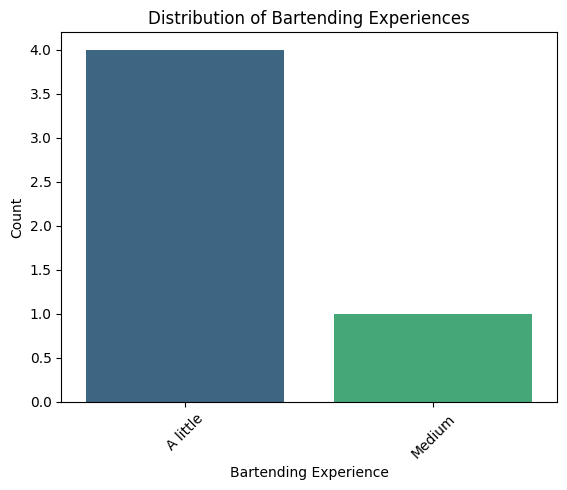

C:\Users\Christian\AppData\Local\Temp\ipykernel_11296\208643279.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pre_df, x="VR", palette="viridis")


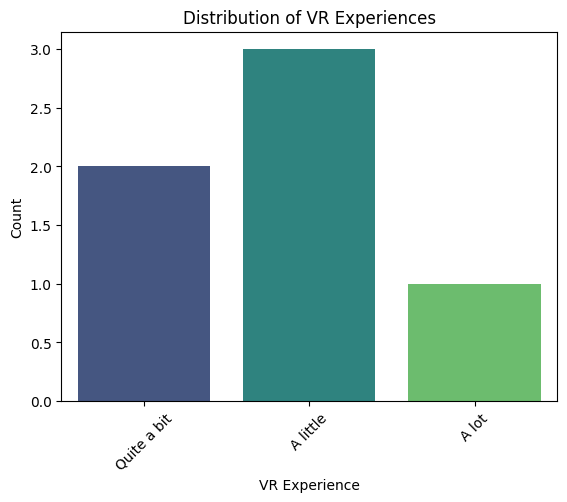

C:\Users\Christian\AppData\Local\Temp\ipykernel_11296\208643279.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pre_df, x="What is your age?", palette="viridis")


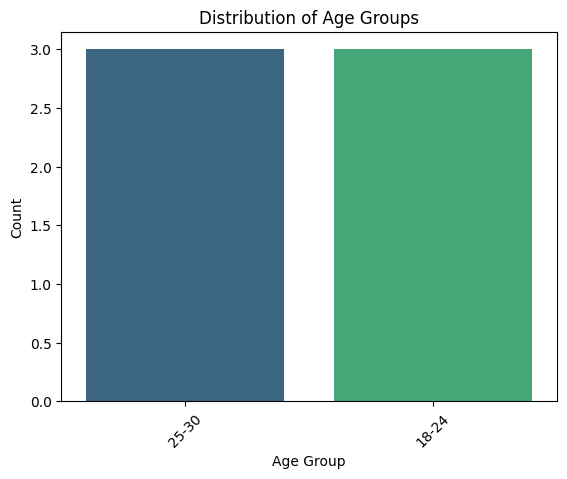

Bartending Experience Counts:
  Bartending  Count
0   A little      4
1     Medium      1
2        NaN      1

VR Experience Counts:
            VR  Count
0     A little      3
1  Quite a bit      2
2        A lot      1

Age Group Counts:
  Age Group  Count
0     25-30      3
1     18-24      3


In [125]:
# Plot distributions for Bartending, VR, and Age
sns.countplot(data=pre_df, x="Bartending", palette="viridis")
plt.title("Distribution of Bartending Experiences")
plt.xlabel("Bartending Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

sns.countplot(data=pre_df, x="VR", palette="viridis")
plt.title("Distribution of VR Experiences")
plt.xlabel("VR Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

sns.countplot(data=pre_df, x="What is your age?", palette="viridis")
plt.title("Distribution of Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Give value counts in a dataframe for each variable
bartending_counts = pre_df["Bartending"].value_counts(dropna=False).rename_axis("Bartending").reset_index(name="Count")
vr_counts = pre_df["VR"].value_counts(dropna=False).rename_axis("VR").reset_index(name="Count")
age_counts = pre_df["What is your age?"].value_counts(dropna=False).rename_axis("Age Group").reset_index(name="Count")

print("Bartending Experience Counts:")
print(bartending_counts)
print("\nVR Experience Counts:")
print(vr_counts)
print("\nAge Group Counts:")
print(age_counts)


# Post questioner  

## Nasa-TLX

In [126]:
# uses the pertable https://www.tandfonline.com/doi/full/10.1080/00140139.2021.1876927?scroll=top&needAccess=true
def interpret_tlx_quartile(score):
    if score < 25:
        return "Very Low"
    elif score < 50:
        return "Low"
    elif score < 75:
        return "High"
    else:
        return "Very High"

In [127]:
tlx_columns = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Performance",
    "Effort",
    "Frustration Level"
]

# Extract first TLX (columns 8-13)
tlx_first = post_pf.iloc[:, 8:14].copy()
tlx_first.columns = tlx_columns
tlx_first["Performance"] = tlx_first["Performance"].apply(lambda x: 21 - x if pd.notna(x) else x)
tlx_first = tlx_first.applymap(lambda x: min(x, 20) if pd.notna(x) else x)
tlx_first = tlx_first.applymap(lambda x: x * 5 if pd.notna(x) else x)
tlx_first["ID"] = post_pf.iloc[:, 6]
tlx_first["Group"] = post_pf.iloc[:, 7]
tlx_first["Version"] = "First"
tlx_first["TLX Score"] = tlx_first[tlx_columns].mean(axis=1)
tlx_first["Interpretation"] = tlx_first["TLX Score"].apply(interpret_tlx_quartile)

tlx_second = post_pf.iloc[:, 14:20].copy()
tlx_second.columns = tlx_columns
tlx_second["Performance"] = tlx_second["Performance"].apply(lambda x: 21 - x if pd.notna(x) else x)
tlx_second = tlx_second.applymap(lambda x: min(x, 20) if pd.notna(x) else x)
tlx_second = tlx_second.applymap(lambda x: x * 5 if pd.notna(x) else x)
tlx_second["ID"] = post_pf.iloc[:, 6]
tlx_second["Group"] = post_pf.iloc[:, 7].apply(swap_group)  # Swap group here!
tlx_second["Version"] = "Second"
tlx_second["TLX Score"] = tlx_second[tlx_columns].mean(axis=1)
tlx_second["Interpretation"] = tlx_second["TLX Score"].apply(interpret_tlx_quartile)


TLX_allScore = pd.concat([tlx_first, tlx_second], ignore_index=True)

for version in ["First", "Second"]:
    mean_tlx = TLX_allScore[TLX_allScore["Version"] == version]["TLX Score"].mean()
    mean_interpretation = interpret_tlx_quartile(mean_tlx)
    print(f"Mean TLX Score ({version}): {mean_tlx:.2f} ({mean_interpretation})")

    omega_value = calculate_omega(
        TLX_allScore[TLX_allScore["Version"] == version][tlx_columns]
    )
    print(f"The reliability of the Nasa-TLX ({version}) was {interpret_omega(omega_value)}, with a McDonald's Omega (TLX combined) = {omega_value:.3f}")

TLX_filtered = TLX_allScore[~TLX_allScore["ID"].isin([101, 102, 103])].reset_index(drop=True)
TLX_allScore

Mean TLX Score (First): 40.97 (Low)
The reliability of the Nasa-TLX (First) was Good, with a McDonald's Omega (TLX combined) = 0.769
Mean TLX Score (Second): 34.44 (Low)
The reliability of the Nasa-TLX (Second) was Good, with a McDonald's Omega (TLX combined) = 0.876


C:\Users\Christian\AppData\Local\Temp\ipykernel_11296\1922839584.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tlx_first = tlx_first.applymap(lambda x: min(x, 20) if pd.notna(x) else x)
C:\Users\Christian\AppData\Local\Temp\ipykernel_11296\1922839584.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tlx_first = tlx_first.applymap(lambda x: x * 5 if pd.notna(x) else x)
C:\Users\Christian\AppData\Local\Temp\ipykernel_11296\1922839584.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tlx_second = tlx_second.applymap(lambda x: min(x, 20) if pd.notna(x) else x)
C:\Users\Christian\AppData\Local\Temp\ipykernel_11296\1922839584.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tlx_second = tlx_second.applymap(lambda x: x * 5 if pd.notna(x) else x)


,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level,ID,Group,Version,TLX Score,Interpretation
0,30.0,20.0,60.0,45.0,15.0,25.0,101,A,First,32.500000,Low
1,75.0,15.0,30.0,90.0,65.0,75.0,102,B,First,58.333333,High
2,70.0,25.0,100.0,35.0,50.0,5.0,103,A,First,47.500000,Low
3,100.0,50.0,5.0,100.0,80.0,5.0,104,B,First,56.666667,High
4,10.0,15.0,20.0,15.0,15.0,5.0,105,A,First,13.333333,Very Low
5,55.0,30.0,20.0,90.0,25.0,5.0,106,B,First,37.500000,Low
6,NaN,NaN,NaN,NaN,NaN,NaN,101,B,Second,NaN,Very High
7,NaN,NaN,NaN,NaN,NaN,NaN,102,A,Second,NaN,Very High
8,NaN,NaN,NaN,NaN,NaN,NaN,103,B,Second,NaN,Very High
9,20.0,20.0,100.0,5.0,50.0,5.0,104,A,Second,33.333333,Low


In [128]:
cols_to_check = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Performance",
    "Effort",
    "Frustration Level",
    "TLX Score"
]

summary_rows = []
for col in cols_to_check:
    # Drop NaN for this column
    #df_nonan = TLX_filtered.dropna(subset=[col])
    for group in Group_name:
        group_data = TLX_filtered[TLX_filtered["Group"] == group][col]
        summary = {
            "Measure": col,
            "Group": group,
            "Mean": group_data.mean(),
            "Std": group_data.std(),
            "Min": group_data.min(),
            "Max": group_data.max()
        }
        summary_rows.append(summary)
    # Statistical test
    test_type, p_value = compare_two_groups(TLX_filtered, score_col=col, group_col="Group")
    summary_rows[-1]["p-value"] = p_value
    summary_rows[-2]["p-value"] = p_value
    summary_rows[-1]["Test"] = "t-test" if test_type == 1 else "Mann-Whitney U" if test_type == 0 else "N/A"
    summary_rows[-2]["Test"] = summary_rows[-1]["Test"]

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df[["Measure", "Group", "Mean", "Std", "Min", "Max", "p-value", "Test"]]
summary_df["Significant"] = summary_df["p-value"] < 0.05

# Format numeric columns to 3 decimals
for col in ["Mean", "Std", "Min", "Max", "p-value"]:
    summary_df[col] = summary_df[col].apply(lambda x: f"{x:.2f}")

summary_df


c:\Users\Christian\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)



# Comparison for 'Mental Demand' between two groups in 'Group' #

Group 1: B (n=3)
Group 2: A (n=3)

## Shapiro–Wilk Test for Normality ##
  B: Stat = 0.8811, p = 0.3275 → Normal
  A: Stat = 0.9868, p = 0.7804 → Normal

## Levene’s Test for Equal Variances ##
  Stat = 0.4865, p = 0.5239 → Equal variances

# Final Group Comparison Test for 'Mental Demand' #
✅ All assumptions met. Running independent t-test:
  t-test: Stat = 2.4445, p = 0.0709

# Comparison for 'Physical Demand' between two groups in 'Group' #

Group 1: B (n=3)
Group 2: A (n=3)

## Shapiro–Wilk Test for Normality ##
  B: Stat = 0.9231, p = 0.4633 → Normal
  A: Stat = 0.9643, p = 0.6369 → Normal

## Levene’s Test for Equal Variances ##
  Stat = 0.1000, p = 0.7676 → Equal variances

# Final Group Comparison Test for 'Physical Demand' #
✅ All assumptions met. Running independent t-test:
  t-test: Stat = 2.2361, p = 0.0890

# Comparison for 'Temporal Demand' between two groups in 'Group' #

Group 1: B (n=3)
Group 2: A (n=3)

,Measure,Group,Mean,Std,Min,Max,p-value,Test,Significant
0,Mental Demand,A,21.67,12.58,10.00,35.00,0.07,t-test,False
1,Mental Demand,B,66.67,29.30,45.00,100.00,0.07,t-test,False
2,Physical Demand,A,21.67,7.64,15.00,30.00,0.09,t-test,False
3,Physical Demand,B,38.33,10.41,30.00,50.00,0.09,t-test,False
4,Temporal Demand,A,46.67,46.19,20.00,100.00,0.64,Mann-Whitney U,False
5,Temporal Demand,B,18.33,12.58,5.00,30.00,0.64,Mann-Whitney U,False
6,Performance,A,16.67,12.58,5.00,30.00,0.03,t-test,True
7,Performance,B,78.33,29.30,45.00,100.00,0.03,t-test,True
8,Effort,A,43.33,25.66,15.00,65.00,0.58,t-test,False
9,Effort,B,56.67,28.43,25.00,80.00,0.58,t-test,False


In [129]:

print_out_latex_from_dataframe(summary_df, "TLX Subscales")


\begin{figure}
\centering
\begin{tabular}{llllllllr}
\toprule
Measure & Group & Mean & Std & Min & Max & P Value & Test & Significant \\
\midrule
Mental Demand & A & 21.67 & 12.58 & 10.00 & 35.00 & 0.07 & t-test & False \\
Mental Demand & B & 66.67 & 29.30 & 45.00 & 100.00 & 0.07 & t-test & False \\
Physical Demand & A & 21.67 & 7.64 & 15.00 & 30.00 & 0.09 & t-test & False \\
Physical Demand & B & 38.33 & 10.41 & 30.00 & 50.00 & 0.09 & t-test & False \\
Temporal Demand & A & 46.67 & 46.19 & 20.00 & 100.00 & 0.64 & Mann-Whitney U & False \\
Temporal Demand & B & 18.33 & 12.58 & 5.00 & 30.00 & 0.64 & Mann-Whitney U & False \\
Performance & A & 16.67 & 12.58 & 5.00 & 30.00 & 0.03 & t-test & True \\
Performance & B & 78.33 & 29.30 & 45.00 & 100.00 & 0.03 & t-test & True \\
Effort & A & 43.33 & 25.66 & 15.00 & 65.00 & 0.58 & t-test & False \\
Effort & B & 56.67 & 28.43 & 25.00 & 80.00 & 0.58 & t-test & False \\
Frustration Level & A & 8.33 & 5.77 & 5.00 & 15.00 & 0.50 & Mann-Whitney U & Fal

## Feedback and motion sickness

In [130]:
last_6_columns = post_pf.iloc[:, -6:]
last_6_columns


,I experienced motion sickness,I felt comfortable using the system,I felt uncomfortable using the system,I would like to play more of this,I enjoyed my time,Please provide any written feedback if any
0,1,3,2,3,4,NaN
1,5,3,2,4,4,NaN
2,2,4,3,5,5,5m is a bit short if you don´t know what work ...
3,1,4,1,4,5,"I'm not that short. :( but very good, but y..."
4,1,5,5,5,5,Turning sucks unfortunately
5,1,4,2,4,4,Shaker got stolen :((


### Motion sickness

In [131]:
# Analyze "I experienced motion sickness" scores
motion_sickness_scores = last_6_columns.iloc[:, 0]

mean_score_ms = motion_sickness_scores.mean()
std_score_ms = motion_sickness_scores.std()
min_score_ms = motion_sickness_scores.min()
max_score_ms = motion_sickness_scores.max()

# Interpretation function
def interpret_feedback_score(score):
    if score == 1:
        return "Strongly Disagree (no motion sickness)"
    elif score == 2:
        return "Somewhat Disagree"
    elif score == 3:
        return "Neutral"
    elif score == 4:
        return "Somewhat Agree"
    elif score == 5:
        return "Strongly Agree (high motion sickness)"
    else:
        return "Invalid score"

# Value counts for interpretation
score_counts = motion_sickness_scores.value_counts().sort_index()
interpretations = [f"{i}: {interpret_feedback_score(i)} (n={score_counts.get(i,0)})" for i in range(1,6)]

# Summary for report
print("## Motion Sickness Experience (n={})".format(len(motion_sickness_scores)))
print(f"Mean score: {mean_score_ms:.2f}")
print(f"Standard deviation: {std_score_ms:.2f}")
print(f"Minimum score: {min_score_ms}")
print(f"Maximum score: {max_score_ms}")
print("Score interpretation breakdown:")
for interp in interpretations:
    print("  " + interp)


print("\nInterpretation: Lower mean values indicate less experienced motion sickness. Most participants reported:", interpret_feedback_score(round(mean_score_ms)))

## Motion Sickness Experience (n=6)
Mean score: 1.83
Standard deviation: 1.60
Minimum score: 1
Maximum score: 5
Score interpretation breakdown:
  1: Strongly Disagree (no motion sickness) (n=4)
  2: Somewhat Disagree (n=1)
  3: Neutral (n=0)
  4: Somewhat Agree (n=0)
  5: Strongly Agree (high motion sickness) (n=1)

Interpretation: Lower mean values indicate less experienced motion sickness. Most participants reported: Somewhat Disagree


### Comfortablitly

In [132]:
comfortable_scores = last_6_columns.iloc[:, 1]
uncomfortable_scores = last_6_columns.iloc[:, 2]

reversed_uncomfortable = 6 - uncomfortable_scores

combined_comfort = pd.concat([comfortable_scores, reversed_uncomfortable], axis=1).mean(axis=1)

mean_comfort = combined_comfort.mean()
std_comfort = combined_comfort.std()
min_comfort = combined_comfort.min()
max_comfort = combined_comfort.max()

def interpret_comfort_score(score):
    if score <= 1.5:
        return "Very Uncomfortable"
    elif score <= 2.5:
        return "Uncomfortable"
    elif score <= 3.5:
        return "Neutral"
    elif score <= 4.5:
        return "Comfortable"
    else:
        return "Very Comfortable"

comfort_counts = combined_comfort.round().value_counts().sort_index()
comfort_interpretations = [
    f"{i}: {interpret_comfort_score(i)} (n={comfort_counts.get(i,0)})" for i in range(1,6)
]

print("## Combined Comfort Experience (n={})".format(len(combined_comfort)))
print(f"Mean score: {mean_comfort:.2f}")
print(f"Standard deviation: {std_comfort:.2f}")
print(f"Minimum score: {min_comfort}")
print(f"Maximum score: {max_comfort}")
print("Score interpretation breakdown:")
for interp in comfort_interpretations:
    print("  " + interp)

print("\nInterpretation: Higher mean values indicate greater comfort. Most participants reported:", interpret_comfort_score(round(mean_comfort)))

## Combined Comfort Experience (n=6)
Mean score: 3.67
Standard deviation: 0.52
Minimum score: 3.0
Maximum score: 4.5
Score interpretation breakdown:
  1: Very Uncomfortable (n=0)
  2: Uncomfortable (n=0)
  3: Neutral (n=1)
  4: Comfortable (n=5)
  5: Very Comfortable (n=0)

Interpretation: Higher mean values indicate greater comfort. Most participants reported: Comfortable


### Enjoyment

In [133]:
play_more_scores = last_6_columns.iloc[:, 3]
enjoyed_time_scores = last_6_columns.iloc[:, 4]


def interpret_enjoyment_score(score):
    if score <= 1.5:
        return "Very Low"
    elif score <= 2.5:
        return "Low"
    elif score <= 3.5:
        return "Neutral"
    elif score <= 4.5:
        return "High"
    else:
        return "Very High"

# Analyze separately
for label, scores in [("Desire to Play More", play_more_scores), ("Perceived Enjoyment", enjoyed_time_scores)]:
    mean_val = scores.mean()
    std_val = scores.std()
    min_val = scores.min()
    max_val = scores.max()
    counts = scores.round().value_counts().sort_index()
    interpretations = [f"{i}: {interpret_enjoyment_score(i)} (n={counts.get(i,0)})" for i in range(1,6)]
    print(f"\n## {label} (n={len(scores)})")
    print(f"Mean score: {mean_val:.2f}")
    print(f"Standard deviation: {std_val:.2f}")
    print(f"Minimum score: {min_val}")
    print(f"Maximum score: {max_val}")
    print("Score interpretation breakdown:")
    for interp in interpretations:
        print("  " + interp)
    print(f"Interpretation: Most participants reported: {interpret_enjoyment_score(round(mean_val))}")

# Combined enjoyment score
combined_enjoyment = pd.concat([play_more_scores, enjoyed_time_scores], axis=1).mean(axis=1)
mean_combined = combined_enjoyment.mean()
print(f"\n## Combined Enjoyment Score (mean): {mean_combined:.2f} ({interpret_enjoyment_score(round(mean_combined))})")


## Desire to Play More (n=6)
Mean score: 4.17
Standard deviation: 0.75
Minimum score: 3
Maximum score: 5
Score interpretation breakdown:
  1: Very Low (n=0)
  2: Low (n=0)
  3: Neutral (n=1)
  4: High (n=3)
  5: Very High (n=2)
Interpretation: Most participants reported: High

## Perceived Enjoyment (n=6)
Mean score: 4.50
Standard deviation: 0.55
Minimum score: 4
Maximum score: 5
Score interpretation breakdown:
  1: Very Low (n=0)
  2: Low (n=0)
  3: Neutral (n=0)
  4: High (n=3)
  5: Very High (n=3)
Interpretation: Most participants reported: High

## Combined Enjoyment Score (mean): 4.33 (High)


### Provide feedback

In [134]:
feedback = last_6_columns["Please provide any written feedback if any"].dropna()
feedback

2    5m is a bit short if you don´t know what work ...
3    I'm not that short. :(    but very good, but y...
4                          Turning sucks unfortunately
5                                Shaker got stolen :((
Name: Please provide any written feedback if any, dtype: object

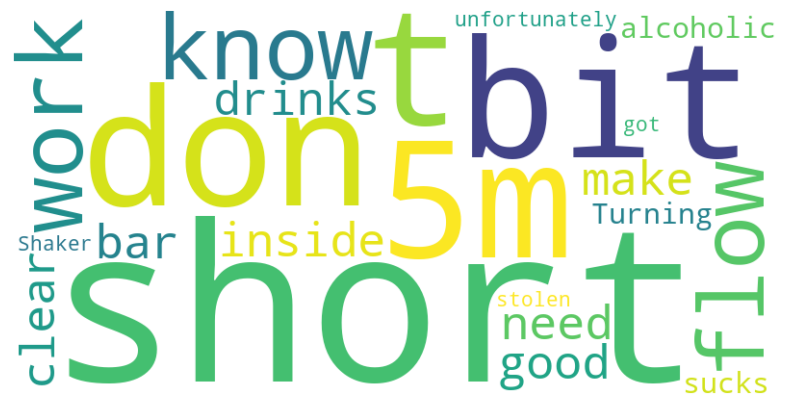

In [135]:

all_text = " ".join(feedback)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [136]:
# Tokenize and remove punctuation
words = [word.strip(string.punctuation) for word in all_text.split()]
# Remove stopwords and empty strings
filtered_words = [word for word in words if word]

# Count word frequencies
word_counts = Counter(filtered_words)
most_common = word_counts.most_common(10)  # Top 10 words

print("Most common words in feedback:")
for word, count in most_common:
    print(f"{word}: {count}")

Most common words in feedback:
short: 2
you: 2
what: 2
to: 2
the: 2
I'm: 2
not: 2
but: 2
5m: 1
is: 1


# Session Data

In [137]:
for participant_id in session_data.keys():
    print(f"Participant ID: {participant_id}")
    for session_type, streams in session_data[participant_id].items():
        print(f"Session: {session_type}")
        for stream_name, df in streams.items():
            if df.shape[0] == 0:
                continue
            print(f"  Stream: {stream_name}, Shape: {df.shape}")
    print("\n")

Participant ID: ses-101
Session: Baseline__old
  Stream: OpenSignals, Shape: (118656, 3)
  Stream: GazePointStream, Shape: (5300, 2)
  Stream: UnityMarkers, Shape: (1, 2)
Session: HighFi_high_difficulty
  Stream: OpenSignals, Shape: (119680, 3)
  Stream: GazePointStream, Shape: (16199, 2)
  Stream: DrinkPerformanceMetrics, Shape: (2, 13)
Session: task-HighFi_low_difficulty
  Stream: GazePointStream, Shape: (17499, 2)
  Stream: OpenSignals, Shape: (125440, 3)


Participant ID: ses-102
Session: Baseline__old
  Stream: OpenSignals, Shape: (119200, 3)
  Stream: UnityMarkers, Shape: (1, 2)
  Stream: GazePointStream, Shape: (1113, 2)
Session: HighFi_high_difficulty
  Stream: GazePointStream, Shape: (16323, 2)
  Stream: OpenSignals, Shape: (122624, 3)
Session: task-HighFi_low_difficulty
  Stream: DrinkPerformanceMetrics, Shape: (1, 13)
  Stream: GazePointStream, Shape: (13234, 2)
  Stream: OpenSignals, Shape: (121856, 3)


Participant ID: ses-103
Session: Baseline__old
  Stream: GazePointStre

## GazePointStream

In [138]:
layer_names = ["Default", "TransparentFX", "Ignore Raycast", "HiddenMesh", "Water", "UI", "Car", "Floor", "TopLayer", "Shaker Bottle", "Shaker Bottle", "Middel point", "Tire", "Bottle", "Strainer", "Glass Dispenser","Garnish Dispenser", "Ice Dispenser", "Book", "Spoon", "Soda gun", "Book", "Customer","Deliver plate"]


Average high difficulty gaze switches: 3968.50
Average low difficulty gaze switches: 5444.33


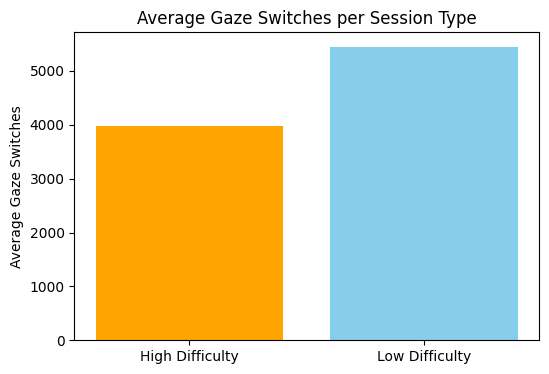


Most common top looked-at layers (high difficulty):
[('Default', 6), ('Shaker Bottle', 4), ('Bottle', 4), ('Unknown (24)', 3), ('Book', 1)]

Most common top looked-at layers (low difficulty):
[('Default', 6), ('Book', 6), ('Bottle', 2), ('Unknown (24)', 2), ('Shaker Bottle', 2)]

Example of longest gaze sessions (high difficulty):
[('Shaker Bottle', 8034, 8995, 962), ('Bottle', 2705, 3300, 596), ('Book', 4032, 4521, 490)]
[('Bottle', 7636, 9271, 1636), ('Default', 2265, 3602, 1338), ('Book', 13819, 14957, 1139)]

Example of longest gaze sessions (low difficulty):
[('Book', 15961, 17118, 1158), ('Unknown (24)', 11, 955, 945), ('Default', 2165, 2905, 741)]
[('Book', 11644, 13053, 1410), ('Unknown (24)', 5057, 6136, 1080), ('Default', 9380, 10071, 692)]


In [139]:
all_high_switches = []
all_low_switches = []
all_high_top_layers = []
all_low_top_layers = []
all_high_longest = []
all_low_longest = []

for participant_id, session_dict in session_data.items():
    high_gaze = session_dict.get("HighFi_high_difficulty", {}).get("GazePointStream")
    low_gaze = session_dict.get("task-HighFi_low_difficulty", {}).get("GazePointStream")
    if high_gaze is None or low_gaze is None:
        continue

    # Convert GazePoint to numeric
    high_gaze["GazePoint"] = pd.to_numeric(high_gaze["GazePoint"], errors="coerce")
    low_gaze["GazePoint"] = pd.to_numeric(low_gaze["GazePoint"], errors="coerce")

    # Gaze switches
    def count_gaze_switches(gaze_df):
        valid_gaze = gaze_df["GazePoint"].dropna().astype(int)
        switches = (valid_gaze != valid_gaze.shift()).sum() - 1
        return switches

    high_switches = count_gaze_switches(high_gaze)
    low_switches = count_gaze_switches(low_gaze)
    all_high_switches.append(high_switches)
    all_low_switches.append(low_switches)

    # Most looked-at layers
    def most_looked_layers(gaze_df, n=3):
        valid_gaze = gaze_df["GazePoint"].dropna().astype(int)
        if not valid_gaze.empty:
            top = valid_gaze.value_counts().head(n)
            result = []
            for idx, count in top.items():
                layer = layer_names[idx] if 0 <= idx < len(layer_names) else f"Unknown ({idx})"
                result.append((layer, count))
            return result
        return []

    all_high_top_layers.append(most_looked_layers(high_gaze))
    all_low_top_layers.append(most_looked_layers(low_gaze))

    # Longest gaze sessions
    def get_gaze_sessions(gaze_df):
        valid_gaze = gaze_df["GazePoint"].dropna().astype(int).reset_index(drop=True)
        sessions = []
        if valid_gaze.empty:
            return sessions
        start_idx = 0
        current_layer = valid_gaze.iloc[0]
        for idx in range(1, len(valid_gaze)):
            if valid_gaze.iloc[idx] != current_layer:
                sessions.append((current_layer, start_idx, idx - 1, idx - start_idx))
                start_idx = idx
                current_layer = valid_gaze.iloc[idx]
        sessions.append((current_layer, start_idx, len(valid_gaze) - 1, len(valid_gaze) - start_idx))
        return sessions

    def longest_gaze_sessions(gaze_df, n=3):
        sessions = get_gaze_sessions(gaze_df)
        if not sessions:
            return []
        layer_sessions = {}
        for layer, start, end, length in sessions:
            if layer not in layer_sessions or length > layer_sessions[layer][2]:
                layer_sessions[layer] = (start, end, length)
        sorted_sessions = sorted(layer_sessions.items(), key=lambda x: x[1][2], reverse=True)
        result = []
        for layer, (start, end, length) in sorted_sessions[:n]:
            layer_name = layer_names[layer] if 0 <= layer < len(layer_names) else f"Unknown ({layer})"
            result.append((layer_name, start, end, length))
        return result

    all_high_longest.append(longest_gaze_sessions(high_gaze))
    all_low_longest.append(longest_gaze_sessions(low_gaze))

# Calculate averages
avg_high_switches = np.mean(all_high_switches)
avg_low_switches = np.mean(all_low_switches)

print(f"Average high difficulty gaze switches: {avg_high_switches:.2f}")
print(f"Average low difficulty gaze switches: {avg_low_switches:.2f}")

# Plot
plt.figure(figsize=(6,4))
plt.bar(['High Difficulty', 'Low Difficulty'], [avg_high_switches, avg_low_switches], color=['orange', 'skyblue'])
plt.ylabel('Average Gaze Switches')
plt.title('Average Gaze Switches per Session Type')
plt.show()

# Optionally, print most common top layers and longest sessions
from collections import Counter

def flatten_layer_counts(layer_lists):
    flat = []
    for layers in layer_lists:
        flat.extend([layer for layer, count in layers])
    return flat

print("\nMost common top looked-at layers (high difficulty):")
print(Counter(flatten_layer_counts(all_high_top_layers)).most_common(5))

print("\nMost common top looked-at layers (low difficulty):")
print(Counter(flatten_layer_counts(all_low_top_layers)).most_common(5))

print("\nExample of longest gaze sessions (high difficulty):")
for session in all_high_longest[:2]:
    print(session)

print("\nExample of longest gaze sessions (low difficulty):")
for session in all_low_longest[:2]:
    print(session)

In [140]:
session_data

{'ses-101': {'Baseline__old': {'OpenSignals':             nSeq      BVP0    time_stamps
   0        32880.0  0.506985  271688.577626
   1        32881.0  0.508626  271688.580125
   2        32882.0  0.509378  271688.582624
   3        32883.0  0.508456  271688.585123
   4        32884.0  0.506606  271688.587623
   ...          ...       ...            ...
   118651  151531.0  0.492552  271985.107842
   118652  151532.0  0.489053  271985.110341
   118653  151533.0  0.486233  271985.112840
   118654  151534.0  0.483822  271985.115339
   118655  151535.0  0.482842  271985.117839
   
   [118656 rows x 3 columns],
   'GazePointStream':      GazePoint    time_stamps
   0            0  271686.620786
   1            0  271686.634884
   2            0  271686.663195
   3            0  271686.677660
   4            0  271686.690542
   ...        ...            ...
   5295         0  271953.937724
   5296         0  271953.951289
   5297         0  271953.971447
   5298         0  271953.995979
 

In [141]:
from collections import defaultdict

high_layer_durations = defaultdict(int)
low_layer_durations = defaultdict(int)

for participant_id, session_dict in session_data.items():
    high_gaze = session_dict.get("HighFi_high_difficulty", {}).get("GazePointStream")
    low_gaze = session_dict.get("task-HighFi_low_difficulty", {}).get("GazePointStream")
    if high_gaze is None or low_gaze is None:
        continue

    # Convert GazePoint to numeric
    high_gaze["GazePoint"] = pd.to_numeric(high_gaze["GazePoint"], errors="coerce")
    low_gaze["GazePoint"] = pd.to_numeric(low_gaze["GazePoint"], errors="coerce")

    def get_gaze_sessions(gaze_df):
        valid_gaze = gaze_df["GazePoint"].dropna().astype(int).reset_index(drop=True)
        sessions = []
        if valid_gaze.empty:
            return sessions
        start_idx = 0
        current_layer = valid_gaze.iloc[0]
        for idx in range(1, len(valid_gaze)):
            if valid_gaze.iloc[idx] != current_layer:
                sessions.append((current_layer, start_idx, idx - 1, idx - start_idx))
                start_idx = idx
                current_layer = valid_gaze.iloc[idx]
        sessions.append((current_layer, start_idx, len(valid_gaze) - 1, len(valid_gaze) - start_idx))
        return sessions

    # Sum durations for each layer in high difficulty
    for layer, start, end, length in get_gaze_sessions(high_gaze):
        high_layer_durations[layer] += length

    # Sum durations for each layer in low difficulty
    for layer, start, end, length in get_gaze_sessions(low_gaze):
        low_layer_durations[layer] += length

# Get the 3 layers with the longest total duration for each difficulty
def get_top_n_layers(layer_durations, n=3):
    sorted_layers = sorted(layer_durations.items(), key=lambda x: x[1], reverse=True)[:n]
    result = []
    for idx, duration in sorted_layers:
        layer_name = layer_names[idx] if 0 <= idx < len(layer_names) else f"Unknown ({idx})"
        result.append((layer_name, duration))
    return result

print("Top 3 layers looked at the longest (high difficulty):")
for layer_name, duration in get_top_n_layers(high_layer_durations, 3):
    print(f"  {layer_name}: {duration} samples")

print("Top 3 layers looked at the longest (low difficulty):")
for layer_name, duration in get_top_n_layers(low_layer_durations, 3):
    print(f"  {layer_name}: {duration} samples")

Top 3 layers looked at the longest (high difficulty):
  Default: 35320 samples
  Bottle: 10366 samples
  Shaker Bottle: 9054 samples
Top 3 layers looked at the longest (low difficulty):
  Default: 40677 samples
  Book: 12249 samples
  Unknown (24): 9747 samples


## Drink performance

In [ ]:
sample_cols = [
    "Ideal Ingredients count", "Actual Ingredients count", "Wrong Ingredients count",
    "Overpour", "Underpour", "Total Pouring Deviation", "Total score", "Correct Glass",
    "Mishandled Ingredients", "Ideal Amount", "Actual Amount", "Time taken"
]

performance_rows = []
for participant_id, session_dict in session_data.items():
    row = {"Participant": participant_id}
    for diff, session_key in [("High", "HighFi_high_difficulty"), ("Low", "task-HighFi_low_difficulty")]:
        metrics_df = session_dict.get(session_key, {}).get("DrinkPerformanceMetrics")
        # Number of drinks delivered
        row[f"{diff}_DrinksDelivered"] = metrics_df.shape[0] if metrics_df is not None and hasattr(metrics_df, "shape") else np.nan
        # Performance metrics
        if metrics_df is not None and not metrics_df.empty:
            means = metrics_df.mean(numeric_only=True)
            for col in sample_cols:
                row[f"{diff}_{col}"] = means.get(col, np.nan)
        else:
            for col in sample_cols:
                row[f"{diff}_{col}"] = np.nan
    performance_rows.append(row)

performance_df = pd.DataFrame(performance_rows)

def percent_correct_glass(perf_df, col):
    vals = perf_df[col].dropna()
    if len(vals) == 0:
        return np.nan
    return 100 * (vals == 1).sum() / len(vals)

high_percent = percent_correct_glass(performance_df, "High_Correct Glass")
low_percent = percent_correct_glass(performance_df, "Low_Correct Glass")

performance_participant_summary = []
for _, row in performance_df.iterrows():
    # High group (A)
    if pd.notna(row["High_DrinksDelivered"]) and row["High_DrinksDelivered"] > 0:
        percent = row["High_Correct Glass"] * 100 if pd.notna(row["High_Correct Glass"]) else np.nan
        performance_participant_summary.append({
            "Participant": row["Participant"],
            "Group": "A",
            "Drinks Delivered": row["High_DrinksDelivered"],
            "Correct Glass (percent)": percent
        })
    # Low group (B)
    if pd.notna(row["Low_DrinksDelivered"]) and row["Low_DrinksDelivered"] > 0:
        percent = row["Low_Correct Glass"] * 100 if pd.notna(row["Low_Correct Glass"]) else np.nan
        performance_participant_summary.append({
            "Participant": row["Participant"],
            "Group": "B",
            "Drinks Delivered": row["Low_DrinksDelivered"],
            "Correct Glass (percent)": percent
        })

performance_participant_summary_df = pd.DataFrame(performance_participant_summary)

# Calculate stats for each group and measure
def group_stats(df, measure):
    stats = df.groupby("Group")[measure].agg(['mean', 'std', 'min', 'max']).reset_index()
    stats.columns = ["Group", "Mean", "Std", "Min", "Max"]
    return stats

stats_correct_glass = group_stats(performance_participant_summary_df, "Correct Glass (percent)")
stats_drinks_delivered = group_stats(performance_participant_summary_df, "Drinks Delivered")

# Statistical tests
test_type1, pval1 = compare_two_groups(performance_participant_summary_df, score_col="Correct Glass (percent)", group_col="Group")
test_type2, pval2 = compare_two_groups(performance_participant_summary_df, score_col="Drinks Delivered", group_col="Group")

test_summary_df = pd.DataFrame([
    {
        "Measure": "Correct Glass (percent)",
        "Mean (A)": stats_correct_glass.loc[stats_correct_glass["Group"] == "A", "Mean"].values[0],
        "Mean (B)": stats_correct_glass.loc[stats_correct_glass["Group"] == "B", "Mean"].values[0],
        "Std (A)": stats_correct_glass.loc[stats_correct_glass["Group"] == "A", "Std"].values[0],
        "Std (B)": stats_correct_glass.loc[stats_correct_glass["Group"] == "B", "Std"].values[0],
        "Min (A)": stats_correct_glass.loc[stats_correct_glass["Group"] == "A", "Min"].values[0],
        "Min (B)": stats_correct_glass.loc[stats_correct_glass["Group"] == "B", "Min"].values[0],
        "Max (A)": stats_correct_glass.loc[stats_correct_glass["Group"] == "A", "Max"].values[0],
        "Max (B)": stats_correct_glass.loc[stats_correct_glass["Group"] == "B", "Max"].values[0],
        "Test": "t-test" if test_type1 == 1 else "Mann-Whitney U" if test_type1 == 0 else "N/A",
        "p-value": pval1
    },
    {
        "Measure": "Drinks Delivered",
        "Mean (A)": stats_drinks_delivered.loc[stats_drinks_delivered["Group"] == "A", "Mean"].values[0],
        "Mean (B)": stats_drinks_delivered.loc[stats_drinks_delivered["Group"] == "B", "Mean"].values[0],
        "Std (A)": stats_drinks_delivered.loc[stats_drinks_delivered["Group"] == "A", "Std"].values[0],
        "Std (B)": stats_drinks_delivered.loc[stats_drinks_delivered["Group"] == "B", "Std"].values[0],
        "Min (A)": stats_drinks_delivered.loc[stats_drinks_delivered["Group"] == "A", "Min"].values[0],
        "Min (B)": stats_drinks_delivered.loc[stats_drinks_delivered["Group"] == "B", "Min"].values[0],
        "Max (A)": stats_drinks_delivered.loc[stats_drinks_delivered["Group"] == "A", "Max"].values[0],
        "Max (B)": stats_drinks_delivered.loc[stats_drinks_delivered["Group"] == "B", "Max"].values[0],
        "Test": "t-test" if test_type2 == 1 else "Mann-Whitney U" if test_type2 == 0 else "N/A",
        "p-value": pval2
    }
])


for idx, row in test_summary_df.iterrows():
    print(f"\n--- {row['Measure']} ---")
    print(f"Group A: Mean={row['Mean (A)']:.2f}, Std={row['Std (A)']:.2f}, Min={row['Min (A)']}, Max={row['Max (A)']}")
    print(f"Group B: Mean={row['Mean (B)']:.2f}, Std={row['Std (B)']:.2f}, Min={row['Min (B)']}, Max={row['Max (B)']}")
    print(f"Test: {row['Test']}, p-value: {row['p-value']:.4f}")


print("\nSummary Table:")
print(test_summary_df)


# Comparison for 'Correct Glass (percent)' between two groups in 'Group' #

Group 1: A (n=4)
Group 2: B (n=4)

## Shapiro–Wilk Test for Normality ##
  A: Stat = 0.9815, p = 0.9109 → Normal
  B: Stat = 0.7286, p = 0.0239 → Not normal

## Levene’s Test for Equal Variances ##
  Stat = 2.7778, p = 0.1466 → Equal variances

# Final Group Comparison Test for 'Correct Glass (percent)' #
❌ Assumptions not met. Using Mann-Whitney U test:
  Mann-Whitney U: Stat = 8.0000, p = 1.0000

# Comparison for 'Drinks Delivered' between two groups in 'Group' #

Group 1: A (n=4)
Group 2: B (n=4)

## Shapiro–Wilk Test for Normality ##
  A: Stat = 0.9447, p = 0.6830 → Normal
  B: Stat = 0.9929, p = 0.9719 → Normal

## Levene’s Test for Equal Variances ##
  Stat = 1.5000, p = 0.2666 → Equal variances

# Final Group Comparison Test for 'Drinks Delivered' #
✅ All assumptions met. Running independent t-test:
  t-test: Stat = -0.6547, p = 0.5370

--- Correct Glass (percent) ---
Group A: Mean=54.17, Std=41.67, Min

## HEART VARIABILTIY 